In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, precision_recall_curve, auc, make_scorer, recall_score, roc_auc_score, matthews_corrcoef, classification_report

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV,learning_curve, train_test_split, cross_validate

### Data

In [3]:
train_data = pd.read_pickle(DATA/'ml_datasets2/L2_TRAIN.pkl')

features = train_data.iloc[:, :10]

# target = train_data[['source']].copy()
train_data['source'] = train_data['source'].str.split('_').str[0] #less specific nitrogen source
train_data['source_type'] = train_data['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

**LABEL ENCODING**

In [4]:
# ---- fit encoders ----
le_type     = LabelEncoder().fit(train_data['source_type'])
le_source   = LabelEncoder().fit(train_data['source'])
le_carbon   = LabelEncoder().fit(train_data.loc[train_data['source_type'] == 'carbon',   'source'])
le_nitrogen = LabelEncoder().fit(train_data.loc[train_data['source_type'] == 'nitrogen', 'source'])

# ---- encode labels ----
y_type   = le_type.transform(train_data['source_type'])
y_source = le_source.transform(train_data['source'])

# ---- masks ----
carbon_mask   = train_data['source_type'] == 'carbon'
nitrogen_mask = train_data['source_type'] == 'nitrogen'

# ---- features ----
X = features

# ---- stage 2 subsets ----
X_c = X[carbon_mask.values]
X_n = X[nitrogen_mask.values]

y_c = le_carbon.transform(train_data.loc[carbon_mask, 'source'])
y_n = le_nitrogen.transform(train_data.loc[nitrogen_mask, 'source'])

### Two stage classification predictor

In [115]:
def make_prediction_proba(
    X,
    binary_clf,
    carbon_clf,
    nitrogen_clf,
    le_type,
    le_source,
    le_carbon,
    le_nitrogen
):
    binary_pred = binary_clf.predict(X).ravel()

    carbon_label = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    # full probability matrix over all source classes
    source_proba = np.zeros((len(X), len(le_source.classes_)))

    if len(carbon_idx) > 0:
        carbon_proba = carbon_clf.predict_proba(X.iloc[carbon_idx])
        carbon_global_idx = le_source.transform(le_carbon.classes_)

        source_proba[np.ix_(carbon_idx, carbon_global_idx)] = carbon_proba

    if len(nitrogen_idx) > 0:
        nitrogen_proba = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])
        nitrogen_global_idx = le_source.transform(le_nitrogen.classes_)

        source_proba[np.ix_(nitrogen_idx, nitrogen_global_idx)] = nitrogen_proba

    return source_proba

In [5]:
def make_prediction(X, binary_clf, carbon_clf, nitrogen_clf, le_type, le_carbon, le_nitrogen):
    binary_pred = binary_clf.predict(X)

    carbon_label   = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx   = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    source_pred = np.empty(len(X), dtype=object)

    if len(carbon_idx) > 0:
        source_pred[carbon_idx]   = le_carbon.inverse_transform(
            carbon_clf.predict(X.iloc[carbon_idx])
        )
    if len(nitrogen_idx) > 0:
        source_pred[nitrogen_idx] = le_nitrogen.inverse_transform(
            nitrogen_clf.predict(X.iloc[nitrogen_idx])
        )

    return binary_pred, source_pred

In [178]:
# # RF pipeline
# binary_pred, source_pred = make_prediction(X_test, rf_binary, rf_carbon, rf_nitrogen, le_type, le_carbon, le_nitrogen)

# # CatBoost pipeline
# binary_pred, source_pred = make_prediction(X_test, cb_binary, cb_carbon, cb_nitrogen, le_type, le_carbon, le_nitrogen)

## Baseline estiamtors

**RandomForest**

In [6]:
rf_binary = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

rf_carbon = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

rf_nitrogen = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

**CatBoost**

In [7]:
cat_binary = CatBoostClassifier(
    verbose=0,
    random_seed=42,
    thread_count=1
)

cat_carbon = CatBoostClassifier(
    verbose=0,
    random_seed=42,
    thread_count=1
)

cat_nitrogen = CatBoostClassifier(
    verbose=0,
    random_seed=42,
    thread_count=1
)

## Tuning

Parameter grid:

In [8]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth':[5, 10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cb_params = {
    'iterations': [100, 300, 500],
    'learning_rate': [0.01, 0.03, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5, 7]
}

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "mcc": make_scorer(matthews_corrcoef)
}

In [10]:
def tune_model(model, param_grid, X, y, model_name, stage_name):
    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        refit="f1_macro",  
        cv=cv,
        n_jobs=3,
        return_train_score=False
    )

    search.fit(X, y)

    i = search.best_index_

    result = {
        "stage": stage_name,
        "model": model_name,
        "best_params": search.best_params_,
        "accuracy": search.cv_results_["mean_test_accuracy"][i],
        "precision_macro": search.cv_results_["mean_test_precision_macro"][i],
        "recall_macro": search.cv_results_["mean_test_recall_macro"][i],
        "f1_macro": search.cv_results_["mean_test_f1_macro"][i],
        "mcc": search.cv_results_["mean_test_mcc"][i],
        "best_estimator": search.best_estimator_
    }

    return result

In [11]:
import sklearn
import catboost

In [12]:
print(sklearn.__version__)
print(catboost.__version__)

1.5.2
1.2.8


### Run tuner:

In [13]:
results = []

# --------------------
# Stage 1: source_type
# --------------------

results.append(
    tune_model(
        rf_binary,
        rf_params,
        X,
        y_type,
        "Random Forest",
        "Stage 1: source_type"
    )
)

results.append(
    tune_model(
        cat_binary,
        cb_params,
        X,
        y_type,
        "CatBoost",
        "Stage 1: source_type"
    )
)


# --------------------
# Stage 2: carbon source
# --------------------

results.append(
    tune_model(
        rf_carbon,
        rf_params,
        X_c,
        y_c,
        "Random Forest",
        "Stage 2: carbon source"
    )
)

results.append(
    tune_model(
        cat_carbon,
        cb_params,
        X_c,
        y_c,
        "CatBoost",
        "Stage 2: carbon source"
    )
)


# --------------------
# Stage 2: nitrogen source
# --------------------

results.append(
    tune_model(
        rf_nitrogen,
        rf_params,
        X_n,
        y_n,
        "Random Forest",
        "Stage 2: nitrogen source"
    )
)

results.append(
    tune_model(
        cat_nitrogen,
        cb_params,
        X_n,
        y_n,
        "CatBoost",
        "Stage 2: nitrogen source"
    )
)

In [14]:
results_df = pd.DataFrame(results)
metrics_df = results_df.drop(columns=["best_estimator", "best_params"])
metrics_df

,stage,model,accuracy,precision_macro,recall_macro,f1_macro,mcc
0,Stage 1: source_type,Random Forest,0.854436,0.856379,0.844003,0.848425,0.700266
1,Stage 1: source_type,CatBoost,0.857020,0.857720,0.847840,0.851551,0.705483
2,Stage 2: carbon source,Random Forest,0.812918,0.828143,0.810366,0.816798,0.764584
3,Stage 2: carbon source,CatBoost,0.824766,0.839145,0.820089,0.826955,0.779741
4,Stage 2: nitrogen source,Random Forest,0.866841,0.873702,0.853651,0.861256,0.792744
5,Stage 2: nitrogen source,CatBoost,0.874295,0.884399,0.858372,0.868020,0.805153


In [15]:
for r in results:
    print("\n", r["stage"], "-", r["model"])
    print(r["best_params"])


 Stage 1: source_type - Random Forest
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

 Stage 1: source_type - CatBoost
{'depth': 8, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}

 Stage 2: carbon source - Random Forest
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

 Stage 2: carbon source - CatBoost
{'depth': 8, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.1}

 Stage 2: nitrogen source - Random Forest
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

 Stage 2: nitrogen source - CatBoost
{'depth': 8, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}


In [16]:
best_rf_binary = results_df.query(
    "stage == 'Stage 1: source_type' and model == 'Random Forest'"
)["best_estimator"].iloc[0]

best_cat_binary = results_df.query(
    "stage == 'Stage 1: source_type' and model == 'CatBoost'"
)["best_estimator"].iloc[0]

best_rf_carbon = results_df.query(
    "stage == 'Stage 2: carbon source' and model == 'Random Forest'"
)["best_estimator"].iloc[0]

best_cat_carbon = results_df.query(
    "stage == 'Stage 2: carbon source' and model == 'CatBoost'"
)["best_estimator"].iloc[0]

best_rf_nitrogen = results_df.query(
    "stage == 'Stage 2: nitrogen source' and model == 'Random Forest'"
)["best_estimator"].iloc[0]

best_cat_nitrogen = results_df.query(
    "stage == 'Stage 2: nitrogen source' and model == 'CatBoost'"
)["best_estimator"].iloc[0]

# Test

plot functions:

In [59]:
def plot_binary_eval_curves(y_true, y_score, figsize=(18, 5), model=None):
    """
    Plot three binary-classification evaluation curves side by side:
    1) Precision-Recall curve
    2) Precision and Recall vs Decision Threshold
    3) ROC curve

    Parameters
    ----------
    y_true : array-like
        True binary labels (0/1 or False/True).
    y_score : array-like
        Predicted scores or probabilities for the positive class.
    figsize : tuple, optional
        Figure size for the subplot layout.
    """

    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # 1) Precision-Recall curve
    axes[0].plot(recall, precision, "b-", alpha=0.5)
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title("Precision–Recall Curve", fontsize=10)

    # 2) Precision and Recall vs threshold
    axes[1].plot(pr_thresholds, precision[:-1], "b--", label="Precision")
    axes[1].plot(pr_thresholds, recall[:-1], "-", label="Recall")
    axes[1].set_xlabel("Decision Threshold")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Score vs Decision Threshold", fontsize=10)
    axes[1].legend()

    # 3) ROC curve
    axes[2].plot(fpr, tpr, "-", color='orange', label=f"AUC = {roc_auc:.3f}")
    axes[2].plot([0, 1], [0, 1], "k--")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_title("ROC Curve", fontsize=10)
    axes[2].legend()

    # Add subplot labels A, B, C
    panel_labels = ["A", "B", "C"]

    for ax, label in zip(axes, panel_labels):
        ax.text(
            0.02, 1.08,
            label,
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='top',
            ha='right'
        )

    plt.suptitle(model, fontsize=15)

    plt.tight_layout()
    plt.show()

In [24]:
test_data = pd.read_pickle('/triumvirate/home/celinaha/thesis_files/data/ml_datasets2/L2_IID_TEST.pkl')

features_test = test_data.iloc[:, :10]

# target = train_data[['source']].copy()
test_data['source'] = test_data['source'].str.split('_').str[0] #less specific nitrogen source
test_data['source_type'] = test_data['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

In [ ]:
# ---- test labels for full pipeline ----
y_test_type = le_type.transform(test_data["source_type"])
y_test_source = test_data["source"]

X_test = features_test

In [34]:
# ---- test labels for stage 2 alone ----
carbon_mask_test = test_data["source_type"] == "carbon"
nitrogen_mask_test = test_data["source_type"] == "nitrogen"

X_c_test = X_test[carbon_mask_test.values]
X_n_test = X_test[nitrogen_mask_test.values]

y_c_test = le_carbon.transform(
    test_data.loc[carbon_mask_test, "source"]
)

y_n_test = le_nitrogen.transform(
    test_data.loc[nitrogen_mask_test, "source"]
)

**MAKE PREDICTION**

In [27]:
rf_binary_pred, rf_source_pred = make_prediction(
    X_test,
    best_rf_binary,
    best_rf_carbon,
    best_rf_nitrogen,
    le_type,
    le_carbon,
    le_nitrogen
)

cat_binary_pred, cat_source_pred = make_prediction(
    X_test,
    best_cat_binary,
    best_cat_carbon,
    best_cat_nitrogen,
    le_type,
    le_carbon,
    le_nitrogen
)

/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


**Stage 1**

In [30]:
def evaluate_predictions(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
    print("F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))
    print("MCC      :", matthews_corrcoef(y_true, y_pred))

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

In [31]:
evaluate_predictions(
    y_test_type,
    rf_binary_pred,
    "RF pipeline: Stage 1 source_type"
)

evaluate_predictions(
    y_test_type,
    cat_binary_pred,
    "CatBoost pipeline: Stage 1 source_type"
)


=== RF pipeline: Stage 1 source_type ===
Accuracy : 0.871900826446281
Precision: 0.8715396689497716
Recall   : 0.864670868347339
F1       : 0.8675213675213675
MCC      : 0.7361784938488656

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       612
           1       0.87      0.91      0.89       840

    accuracy                           0.87      1452
   macro avg       0.87      0.86      0.87      1452
weighted avg       0.87      0.87      0.87      1452


=== CatBoost pipeline: Stage 1 source_type ===
Accuracy : 0.8774104683195593
Precision: 0.877294996194825
Recall   : 0.8703197945845005
F1       : 0.8732193732193732
MCC      : 0.7475822509627351

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       612
           1       0.88      0.92      0.90       840

    accuracy                           0.88      1452
   macro avg       0

In [42]:
print(le_type.classes_)

['carbon' 'nitrogen']


**NITROGEN = TRUE**

In [47]:
cat_binary_scores = best_cat_binary.predict_proba(X_test)[:, 1]
rf_binary_scores = best_rf_binary.predict_proba(X_test)[:, 1]

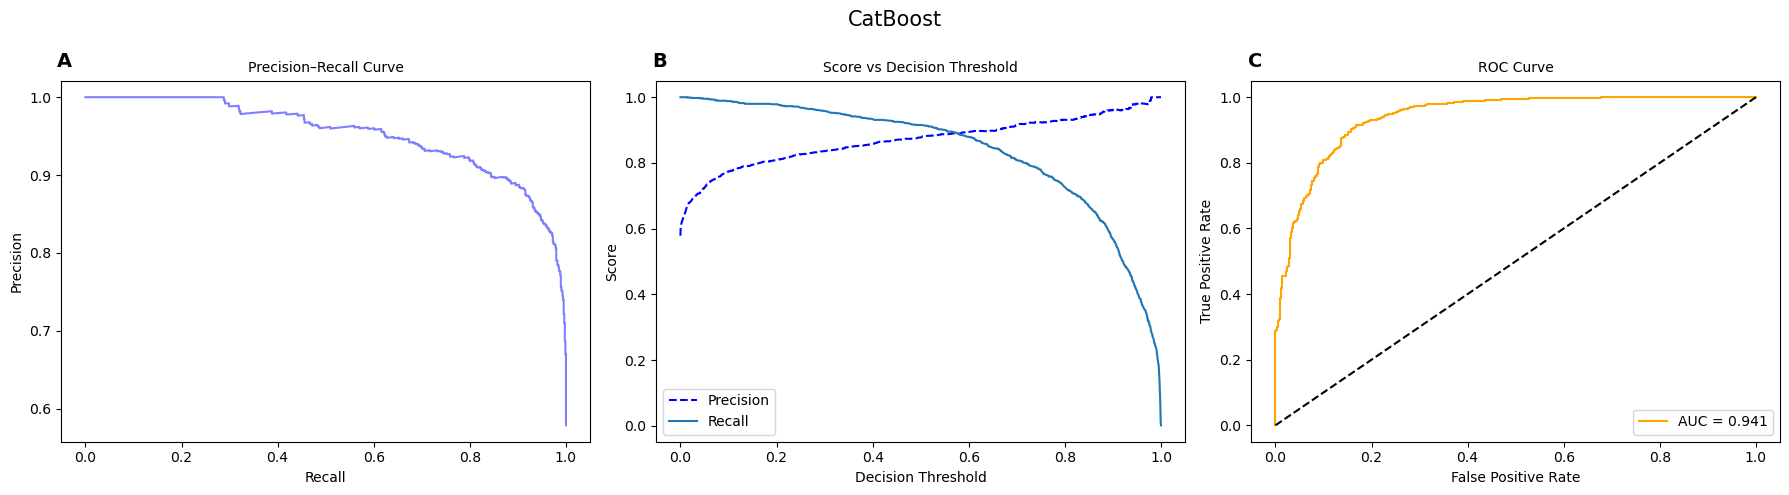

In [69]:
plot_binary_eval_curves(
    y_test_type,
    cat_binary_scores,
    model='CatBoost',
    figsize=(18,5)
)

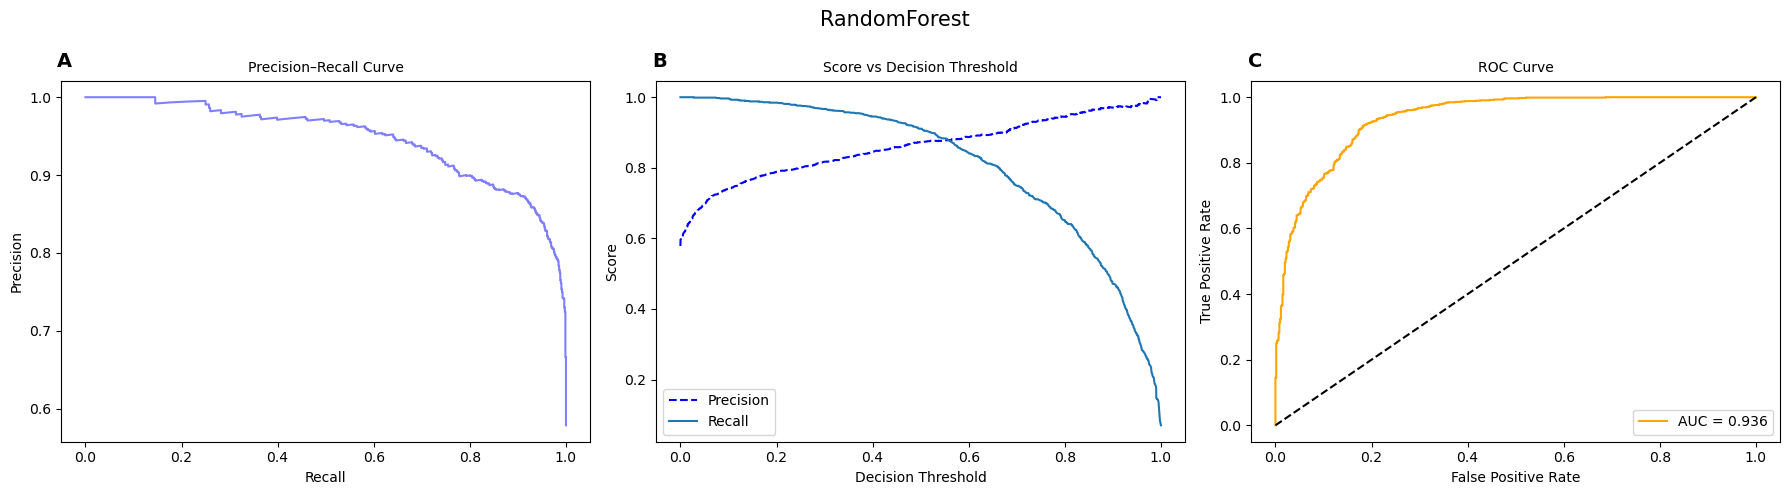

In [61]:
plot_binary_eval_curves(
    y_test_type,
    rf_binary_scores,
    model='RandomForest'
)

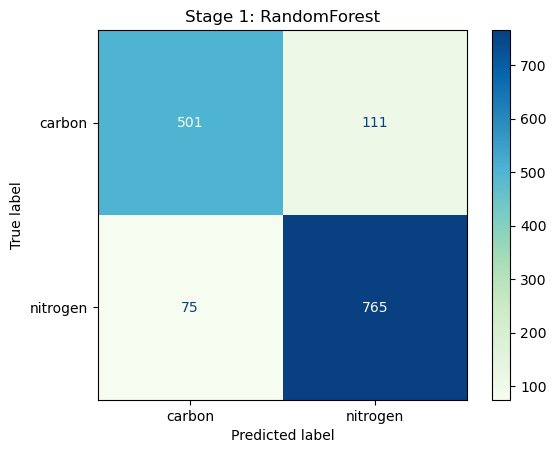

In [111]:
cm = confusion_matrix(y_test_type, rf_binary_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_type.classes_)

disp.plot(cmap='GnBu')
plt.title("Stage 1: RandomForest")
plt.show()


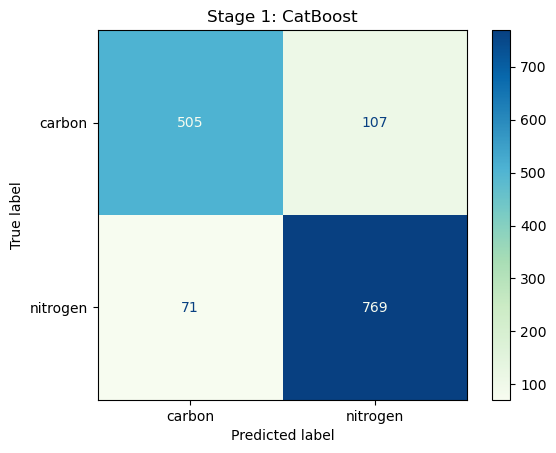

In [110]:
cm = confusion_matrix(y_test_type, cat_binary_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_type.classes_)

disp.plot(cmap='GnBu')
plt.title("Stage 1: CatBoost")
plt.show()

**Stage 2**

In [37]:
def evaluate_stage2_predictions(y_true, y_pred, name, label_encoder):
    print(f"\n=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    print(
        "Recall   :",
        recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    print(
        "F1       :",
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    print(
        "MCC      :",
        matthews_corrcoef(y_true, y_pred)
    )

    print("\nClassification report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

In [35]:
# RF stage 2 alone
rf_c_pred = best_rf_carbon.predict(X_c_test)
rf_n_pred = best_rf_nitrogen.predict(X_n_test)

# CatBoost stage 2 alone
cat_c_pred = best_cat_carbon.predict(X_c_test)
cat_n_pred = best_cat_nitrogen.predict(X_n_test)

In [39]:
evaluate_stage2_predictions(
    y_c_test,
    rf_c_pred,
    "RF Stage 2 carbon",
    le_carbon
)

evaluate_stage2_predictions(
    y_n_test,
    rf_n_pred,
    "RF Stage 2 nitrogen",
    le_nitrogen
)


=== RF Stage 2 carbon ===
Accuracy : 0.8137254901960784
Precision: 0.8301572720530013
Recall   : 0.8146396973722826
F1       : 0.8204027949910022
MCC      : 0.7653477291173942

Classification report:
              precision    recall  f1-score   support

          ac       0.88      0.85      0.87        96
         glc       0.80      0.81      0.81       141
        glyc       0.80      0.68      0.73       116
        lcts       0.73      0.85      0.78       157
        succ       0.94      0.88      0.91       102

    accuracy                           0.81       612
   macro avg       0.83      0.81      0.82       612
weighted avg       0.82      0.81      0.81       612


=== RF Stage 2 nitrogen ===
Accuracy : 0.8821428571428571
Precision: 0.8893945617349872
Recall   : 0.8697391846998146
F1       : 0.8776763066839376
MCC      : 0.8164852182942675

Classification report:
              precision    recall  f1-score   support

         arg       0.86      0.94      0.90       38

In [38]:
evaluate_stage2_predictions(
    y_c_test,
    cat_c_pred,
    "CatBoost Stage 2 carbon",
    le_carbon
)

evaluate_stage2_predictions(
    y_n_test,
    cat_n_pred,
    "CatBoost Stage 2 nitrogen",
    le_nitrogen
)


=== CatBoost Stage 2 carbon ===
Accuracy : 0.8202614379084967
Precision: 0.8406418934827586
Recall   : 0.8189643856196629
F1       : 0.8264484891614137
MCC      : 0.7745456450928941

Classification report:
              precision    recall  f1-score   support

          ac       0.91      0.83      0.87        96
         glc       0.84      0.79      0.82       141
        glyc       0.82      0.69      0.75       116
        lcts       0.72      0.89      0.79       157
        succ       0.92      0.89      0.91       102

    accuracy                           0.82       612
   macro avg       0.84      0.82      0.83       612
weighted avg       0.83      0.82      0.82       612


=== CatBoost Stage 2 nitrogen ===
Accuracy : 0.875
Precision: 0.8828927672314077
Recall   : 0.8604944049825939
F1       : 0.8691702261791918
MCC      : 0.8056464687838116

Classification report:
              precision    recall  f1-score   support

         arg       0.85      0.95      0.90       381

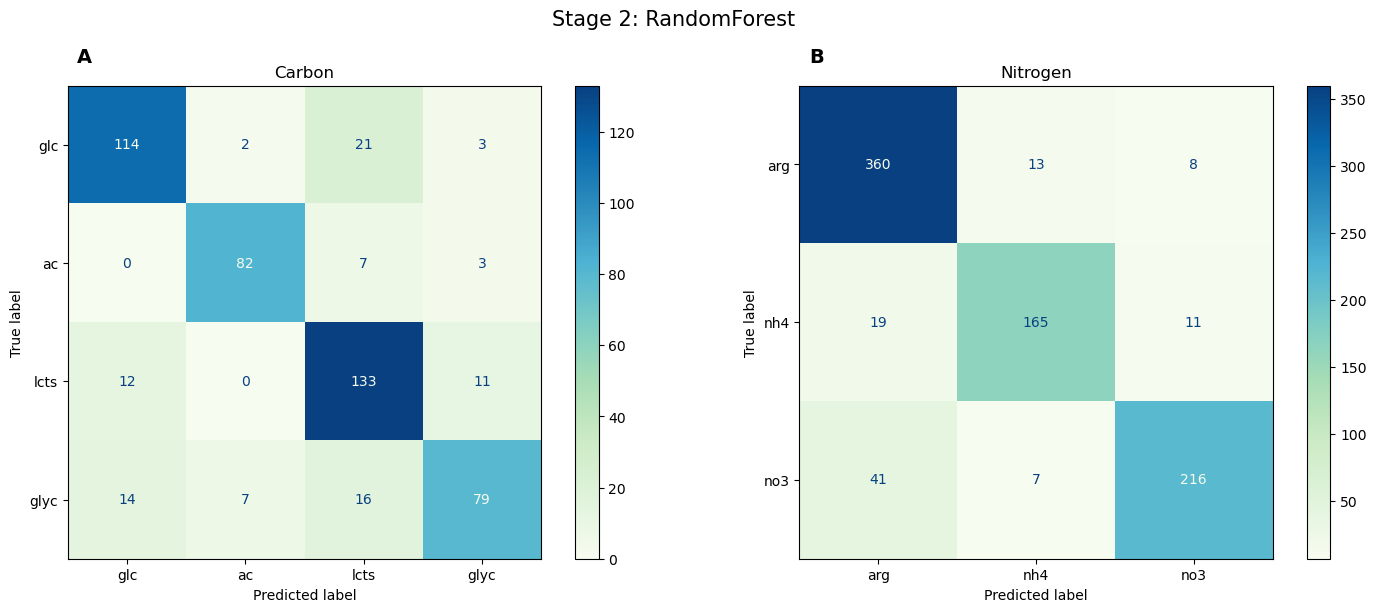

In [134]:
c_order = ['glc', 'ac', 'lcts', 'glyc']
n_order = ['arg', 'nh4', 'no3']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# -------------------
# Carbon
# -------------------

cm_carbon = confusion_matrix(le_carbon.inverse_transform(y_c_test), le_carbon.inverse_transform(rf_c_pred), labels=c_order)
disp_carbon = ConfusionMatrixDisplay(cm_carbon, display_labels=c_order)

disp_carbon.plot(
    cmap='GnBu',
    ax=axes[0],
    colorbar=True
)

axes[0].set_title("Carbon")
axes[0].text(
    0.02, 1.08,
    "A",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    ha='left'
)

# -------------------
# Nitrogen
# -------------------

cm_nitrogen = confusion_matrix(le_nitrogen.inverse_transform(y_n_test), le_nitrogen.inverse_transform(rf_n_pred), labels=n_order)
disp_nitrogen = ConfusionMatrixDisplay(cm_nitrogen,display_labels=n_order)

disp_nitrogen.plot(cmap='GnBu',ax=axes[1],colorbar=True)

axes[1].set_title("Nitrogen")
axes[1].text(
    0.02, 1.08,
    "B",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    ha='left'
)

plt.suptitle('Stage 2: RandomForest', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/triumvirate/home/celinaha/.conda/envs/ML_env/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


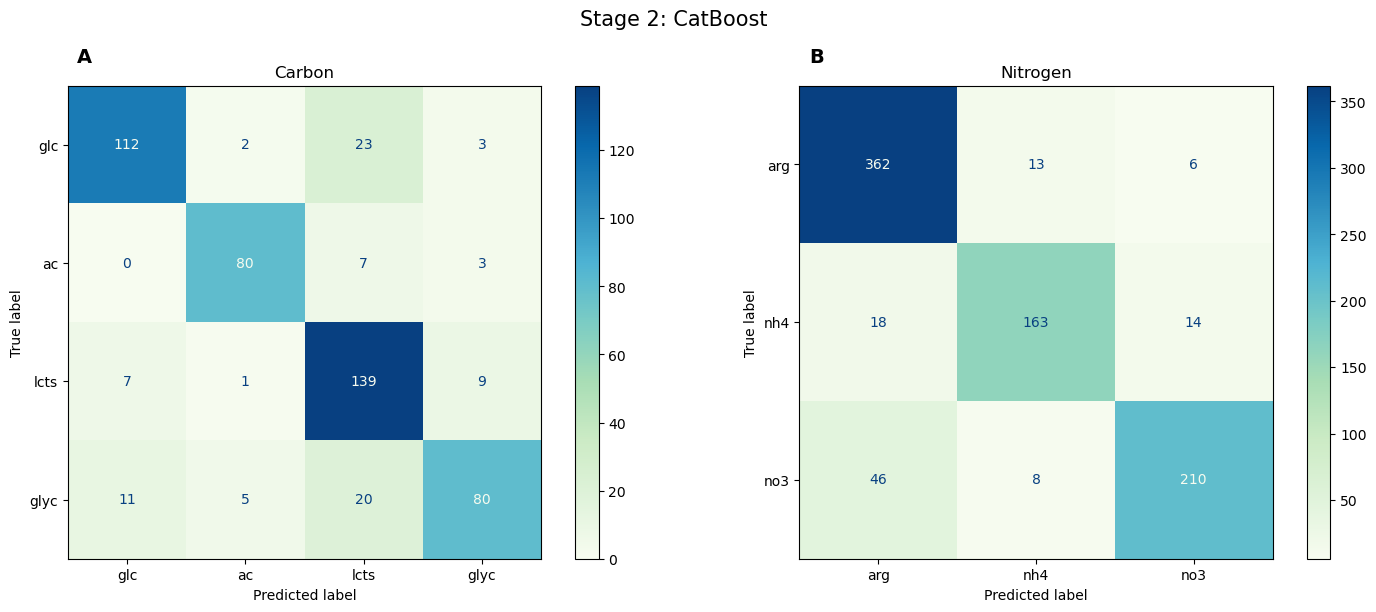

In [135]:
c_order = ['glc', 'ac', 'lcts', 'glyc']
n_order = ['arg', 'nh4', 'no3']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# -------------------
# Carbon
# -------------------

cm_carbon = confusion_matrix(le_carbon.inverse_transform(y_c_test), le_carbon.inverse_transform(cat_c_pred), labels=c_order)
disp_carbon = ConfusionMatrixDisplay(cm_carbon, display_labels=c_order)

disp_carbon.plot(
    cmap='GnBu',
    ax=axes[0],
    colorbar=True
)

axes[0].set_title("Carbon")
axes[0].text(
    0.02, 1.08,
    "A",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    ha='left'
)

# -------------------
# Nitrogen
# -------------------

cm_nitrogen = confusion_matrix(le_nitrogen.inverse_transform(y_n_test), le_nitrogen.inverse_transform(cat_n_pred), labels=n_order)
disp_nitrogen = ConfusionMatrixDisplay(cm_nitrogen,display_labels=n_order)

disp_nitrogen.plot(cmap='GnBu',ax=axes[1],colorbar=True)

axes[1].set_title("Nitrogen")
axes[1].text(
    0.02, 1.08,
    "B",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight='bold',
    va='top',
    ha='left'
)

plt.suptitle('Stage 2: CatBoost', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Full pipeline**

In [32]:
evaluate_predictions(
    y_test_source,
    rf_source_pred,
    "RF full pipeline: final source"
)

evaluate_predictions(
    y_test_source,
    cat_source_pred,
    "CatBoost full pipeline: final source"
)


=== RF full pipeline: final source ===
Accuracy : 0.7493112947658402
Precision: 0.7400497036488052
Recall   : 0.6991064183685247
F1       : 0.7063490800065229
MCC      : 0.7019583817070539

Classification report:
              precision    recall  f1-score   support

          ac       0.68      0.31      0.43        96
         arg       0.76      0.87      0.81       381
         glc       0.67      0.72      0.69       141
        glyc       0.72      0.49      0.58       116
        lcts       0.65      0.82      0.73       157
         nh4       0.80      0.75      0.78       195
         no3       0.82      0.79      0.80       264
        succ       0.83      0.84      0.83       102

    accuracy                           0.75      1452
   macro avg       0.74      0.70      0.71      1452
weighted avg       0.75      0.75      0.74      1452


=== CatBoost full pipeline: final source ===
Accuracy : 0.7555096418732782
Precision: 0.7433200750951547
Recall   : 0.7050207198542169

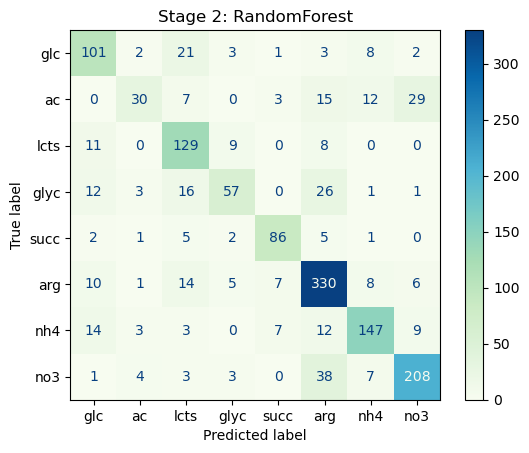

In [109]:
env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg', 'nh4', 'no3']

cm = confusion_matrix(y_test_source, rf_source_pred, labels=env_order)
disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='GnBu')
plt.title("Stage 2: RandomForest")
plt.show()

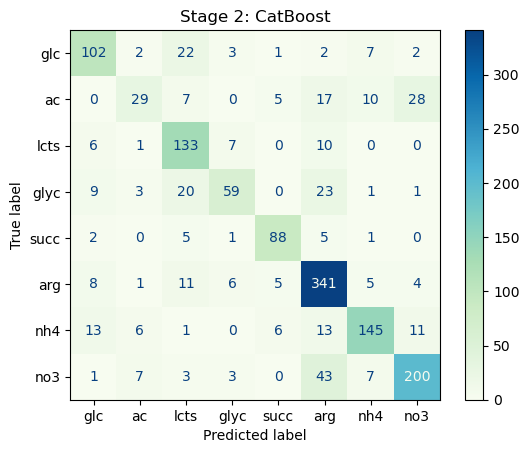

In [112]:
env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg', 'nh4', 'no3']

cm = confusion_matrix(y_test_source, cat_source_pred, labels=env_order)
disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

disp.plot(cmap='GnBu')
plt.title("Stage 2: CatBoost")
plt.show()

In [116]:
rf_source_proba = make_prediction_proba(
    X_test,
    best_rf_binary,
    best_rf_carbon,
    best_rf_nitrogen,
    le_type,
    le_source,
    le_carbon,
    le_nitrogen
)

cat_source_proba = make_prediction_proba(
    X_test,
    best_cat_binary,
    best_cat_carbon,
    best_cat_nitrogen,
    le_type,
    le_source,
    le_carbon,
    le_nitrogen
)

In [119]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_final_pipeline_multiclass_roc(y_true_encoded, y_score, label_encoder, title):
    classes = np.arange(len(label_encoder.classes_))

    y_true_bin = label_binarize(
        y_true_encoded,
        classes=classes
    )

    plt.figure(figsize=(8, 6))

    for i, class_name in enumerate(label_encoder.classes_):

        # skip classes not present in the test set
        if y_true_bin[:, i].sum() == 0:
            print(f"Skipping {class_name}: no positive samples in test set")
            continue

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{class_name} AUC = {roc_auc:.2f}"
        )

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

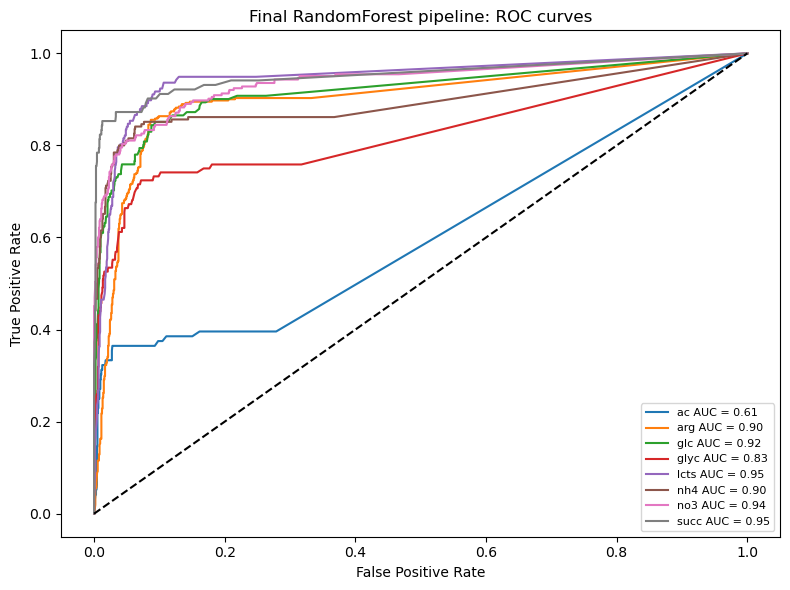

In [121]:
y_test_source_encoded = le_source.transform(y_test_source)

plot_final_pipeline_multiclass_roc(
    y_test_source_encoded,
    rf_source_proba,
    le_source,
    "Final RandomForest pipeline: ROC curves"
)

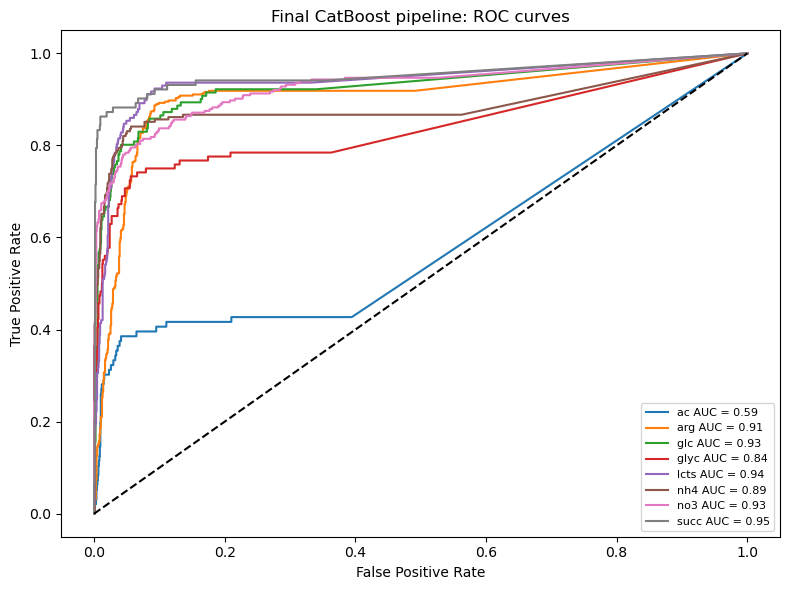

In [120]:
y_test_source_encoded = le_source.transform(y_test_source)

plot_final_pipeline_multiclass_roc(
    y_test_source_encoded,
    cat_source_proba,
    le_source,
    "Final CatBoost pipeline: ROC curves"
)